# 第 5 章 趨勢策略研發與驗證

[![在 Colab 開啟](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/finlab-python/hahow-crypto-course/blob/main/5-2_trend_strategies.ipynb)

**對應影片**：第 5 章 單元 5-1 ~ 5-4【策略研發 I ~ III】、【策略驗證】

**和影片的差異**

- 資料改從 Binance 公開資料端點下載（`data-api.binance.vision`，不需金鑰、Colab 可用），`get_all_binance` 的寫法和影片一樣。
- TA-Lib 已經隨 `finlab_crypto` 一起安裝（官方 wheel），不需要再 `pip install talib-binary`。
- vectorbt 改版：`cumulative_returns()`、`final_value()`、`daily_returns()`、`drawdown()` 都是要加括號的函式；影片寫法不同時，以本筆記本為準。
- 濾網函式（lowpass、detrend 等）改寫成向量化運算，結果和影片相同但快很多。
- Bootstrap 檢定固定亂數種子，重跑結果一致。

In [1]:
%pip install -q finlab_crypto==0.3.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
# QUICK_RUN = True 會縮小最佳化範圍，幾十秒就跑完（自動測試使用）。上課請維持 False。
QUICK_RUN = False

In [3]:
import finlab_crypto

finlab_crypto.setup()

## 5-1 階梯函數：看濾網如何反應趨勢

<Axes: >

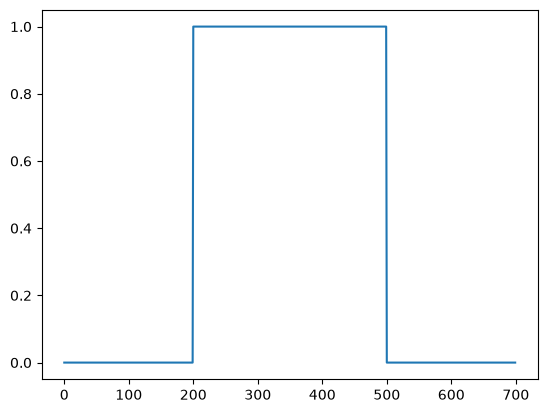

In [4]:
import pandas as pd

s = pd.Series([0] * 200 + [1] * 300 + [0] * 200)
s.plot()

## 5-2 finlab_crypto 內建的 8 種趨勢濾網

在函式後面加 `??` 可以看原始碼。

In [5]:
from finlab_crypto import indicators

indicators.trends

{'sma': <function finlab_crypto.indicators.sma(price, n)>,
 'wma': <function finlab_crypto.indicators.wma(price, n)>,
 'lowpass': <function finlab_crypto.indicators.lowpass(price, n)>,
 'hullma': <function finlab_crypto.indicators.hullma(price, n)>,
 'zlma': <function finlab_crypto.indicators.zlma(price, n)>,
 'alma': <function finlab_crypto.indicators.alma(price, n)>,
 'detrend': <function finlab_crypto.indicators.detrend(price, n)>,
 'linear_reg': <function finlab_crypto.indicators.linear_reg(price, n)>}

In [6]:
indicators.hullma??

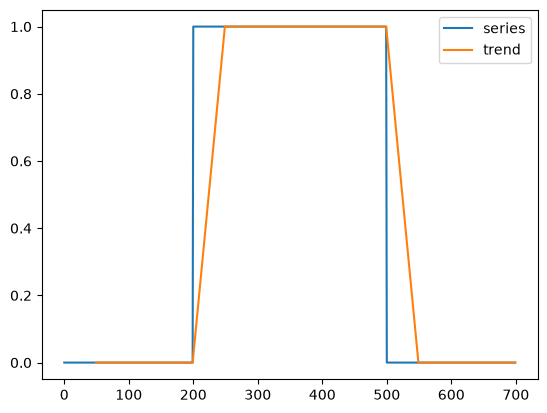

In [7]:
import matplotlib.pyplot as plt

# 50 期簡單移動平均
trend = indicators.trends['sma'](s, 50)

s.plot(label='series')
trend.plot(label='trend')
plt.legend()

### 一次比較所有濾網

[dict 的 items()](https://www.w3schools.com/python/ref_dictionary_items.asp) 同時取出名稱與函式。

<Axes: >

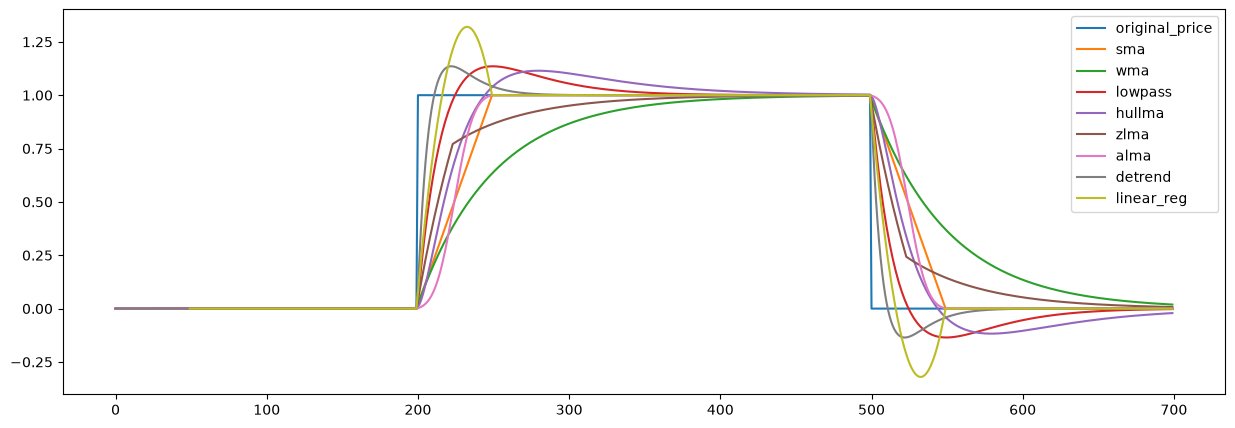

In [8]:
filter_results = pd.DataFrame({'original_price': s})

for name, func in indicators.trends.items():
    filter_results[name] = func(s, 50)

filter_results.plot(figsize=(15, 5))

## 5-3 實戰趨勢策略最佳化

濾網種類也是參數：8 種濾網 × 兩條線的週期，一次全部回測。

In [9]:
ohlcv = finlab_crypto.crawler.get_all_binance('BTCUSDT', '4h')

BTCUSDT 4h: 19936 candles (2017-08-17 ~ 2026-09-24 08:00 UTC)


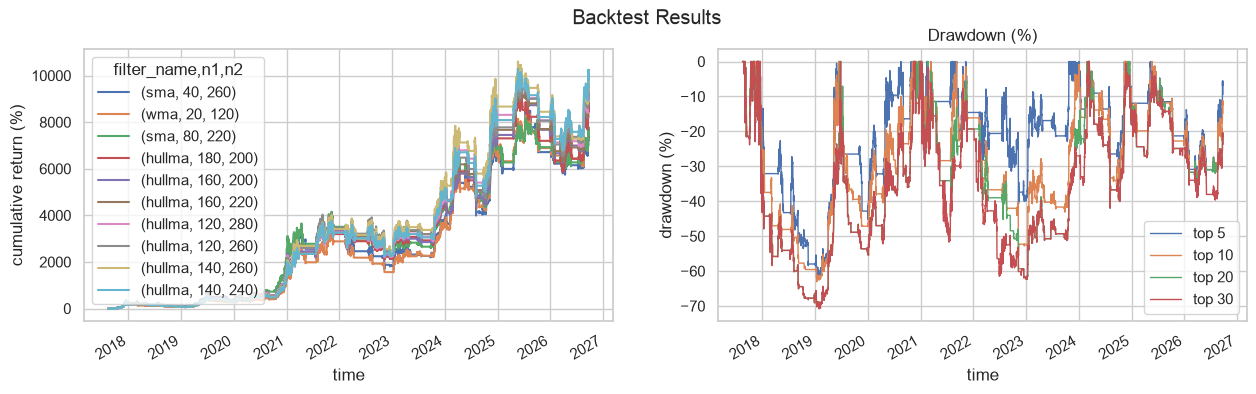

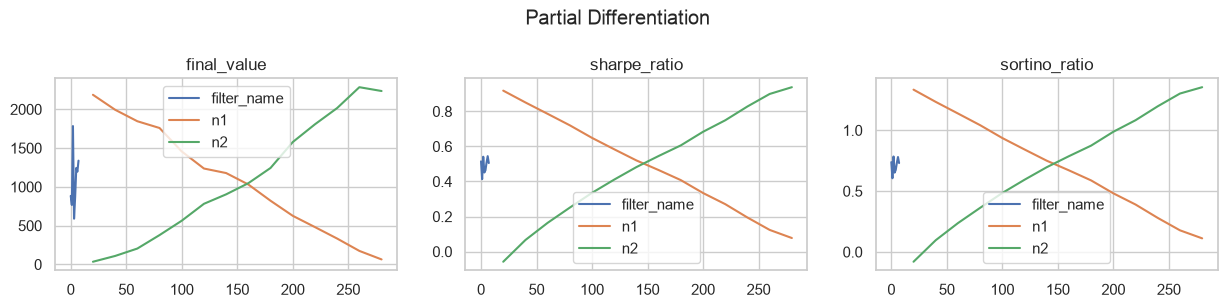

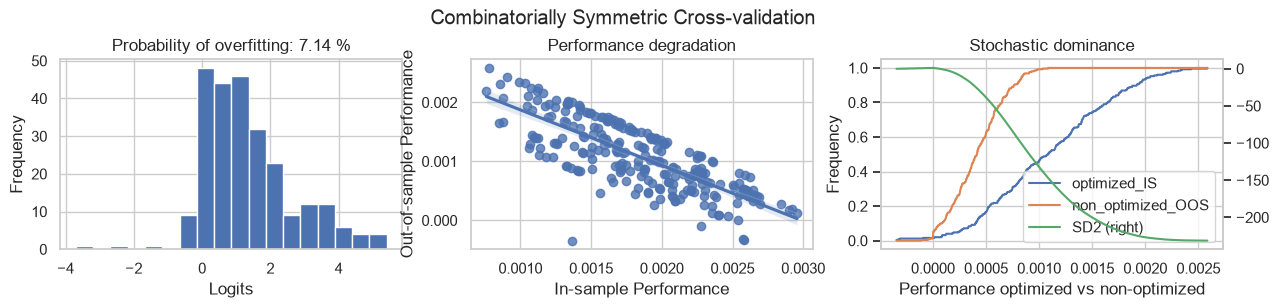

In [10]:
import numpy as np
from finlab_crypto import Strategy


@Strategy(filter_name='sma', n1=20, n2=60)
def trend_strategy(ohlcv):
    filter_name = trend_strategy.filter_name
    close = ohlcv.close
    fast = indicators.trends[filter_name](close, trend_strategy.n1)
    slow = indicators.trends[filter_name](close, trend_strategy.n2)

    entries = (fast > slow) & (fast.shift() < slow.shift())
    exits = (fast < slow) & (fast.shift() > slow.shift())
    return entries, exits


step = 80 if QUICK_RUN else 20
variables = {
    'filter_name': list(indicators.trends),
    'n1': np.arange(20, 300, step),
    'n2': np.arange(20, 300, step),
}
portfolio = trend_strategy.backtest(ohlcv, variables=variables, freq='4h', plot=True)

## 5-4 驗證趨勢策略是否有效：Bootstrap 檢定

問題：最好的參數組合，績效是真的，還是只是從一堆隨機結果裡挑到運氣好的？

1. 把所有參數組合的每日報酬「去掉趨勢」（減掉平均），代表「沒有真本事」的報酬
2. 從中隨機抽樣、組合出 1000 條假想的績效
3. 最佳參數的總報酬若遠在這個分布的右邊，就不太可能只是運氣

### 去除趨勢

[unstack](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.unstack.html) 把所有欄位攤平成一維。

In [11]:
daily_returns = portfolio.daily_returns()
detrend = daily_returns - daily_returns.mean()
samples = detrend.unstack().values

### 重新抽樣

[random.choices](https://docs.python.org/3/library/random.html#random.choices) 可重複抽樣。

<Axes: >

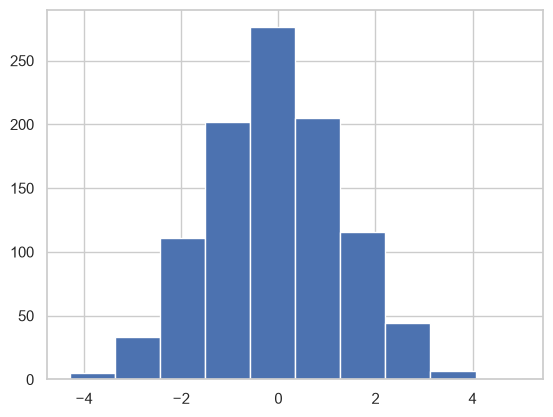

In [12]:
import random

BOOTSTRAP_ROUNDS = 1000
random.seed(0)
ndays = len(daily_returns)

random_returns = [sum(random.choices(samples, k=ndays)) for _ in range(BOOTSTRAP_ROUNDS)]
pd.Series(random_returns).hist()

### 最佳參數落在哪裡？

In [13]:
portfolio.final_value().nlargest(5)

filter_name  n1   n2 
hullma       140  240    9921.682175
                  260    9755.620587
             120  260    9569.746112
                  280    9349.221773
             160  220    9152.280795
Name: final_value, dtype: float64

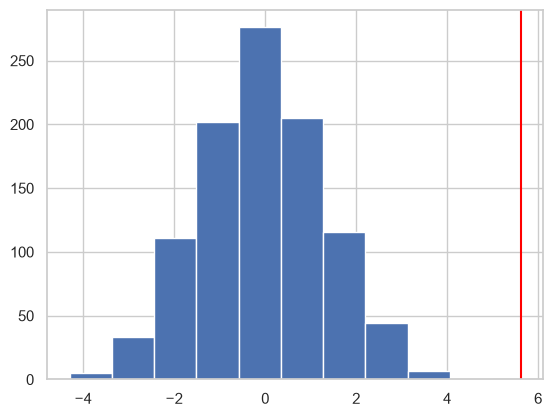

In [14]:
best_result = portfolio.final_value().idxmax()
best_result_value = daily_returns[best_result].sum()

pd.Series(random_returns).hist()
plt.axvline(best_result_value, color='red')

In [15]:
# 隨機結果勝過最佳參數的比例（越小越好）
(pd.Series(random_returns) >= best_result_value).mean()

np.float64(0.0)